# Stage 2: Out-of-Sample PCA Early-Warning Validation - UST Benchmark PCA Extension

## Goal
Use **UST training data** to define the latent instability structure, then project **UST, USDC, DAI, USDT, and PAX/USDP** into that same UST factor space.

This notebook answers:

1. **Main case study**: Could UST-based latent factors warn before the May 2022 UST collapse?
2. **External validation**: Do USDC and DAI show similar UST-style instability before their own depeg episodes?
3. **False-alarm validation**: Do USDT and PAX/USDP remain mostly quiet under the UST benchmark?

In [46]:
# %pip install pandas pyarrow scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Load Data
This notebook expects both the `*_clean.parquet` and `*_final.parquet` files.


In [47]:
DATA_DIR = Path("clean_data")

# event / split reference files
dai_clean  = pd.read_parquet(DATA_DIR / "dai_clean.parquet")
pax_clean  = pd.read_parquet(DATA_DIR / "pax_clean.parquet")
usdc_clean = pd.read_parquet(DATA_DIR / "usdc_clean.parquet")
usdt_clean = pd.read_parquet(DATA_DIR / "usdt_clean.parquet")
ust_clean  = pd.read_parquet(DATA_DIR / "ust_clean.parquet")

# modelling files with engineered features
dai_final  = pd.read_parquet(DATA_DIR / "dai_final.parquet")
pax_final  = pd.read_parquet(DATA_DIR / "pax_final.parquet")
usdc_final = pd.read_parquet(DATA_DIR / "usdc_final.parquet")
usdt_final = pd.read_parquet(DATA_DIR / "usdt_final.parquet")
ust_final  = pd.read_parquet(DATA_DIR / "ust_final.parquet")

for df in [dai_clean, pax_clean, usdc_clean, usdt_clean, ust_clean,
           dai_final, pax_final, usdc_final, usdt_final, ust_final]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

In [48]:
print("Depeg counts")
print("DAI :", int(dai_clean["depeg"].sum()))
print("PAX :", int(pax_clean["depeg"].sum()))
print("USDC:", int(usdc_clean["depeg"].sum()))
print("USDT:", int(usdt_clean["depeg"].sum()))
print("UST :", int(ust_clean.loc[ust_clean["timestamp"] <= "2022-05-11", "depeg"].sum()))

Depeg counts
DAI : 5
PAX : 23
USDC: 3
USDT: 2
UST : 26


## 2. Helper Functions for Splitting and PCA Preparation

In [49]:
def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    split_date = pd.Timestamp(split_date)
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    return train, test

def split_equal_depegs(df, date_col="timestamp", target_col="depeg", end_date="2024-12-31"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    df = df[df[date_col] <= pd.Timestamp(end_date)].copy()
    cumsum = df[target_col].cumsum()
    total = int(cumsum.iloc[-1])
    if total == 0:
        mid = len(df) // 2
        return df.iloc[:mid].copy(), df.iloc[mid:].copy()
    split_idx = (cumsum - total / 2).abs().idxmin()
    train = df.iloc[: split_idx + 1].copy()
    test  = df.iloc[split_idx + 1 :].copy()
    return train, test

def prepare_stablecoin_pca_df(df):
    drop_cols = [
        "depeg", "timeOpen", "timeClose", "timeHigh", "timeLow",
        "open", "high", "low", "close", "volume", "marketCap", "circulatingSupply",
        "depeg_future_1d", "depeg_future_3d", "depeg_future_5d", "depeg_future_7d",
        "depeg_future_14d", "depeg_future_21d", "depeg_future_30d"
    ]
    keep = [c for c in df.columns if c not in drop_cols]
    out = df[keep].copy()
    if "symbol" not in out.columns:
        out["symbol"] = np.nan
    return out

def get_feature_columns(df):
    return [c for c in df.columns if c not in ["timestamp", "symbol"]]

## 3. Train-Test Splits

### Design
- **UST** is the benchmark model.  
  We train on pre-collapse UST and test on the run-up to / collapse period.
- **USDC / DAI / USDT** use coin-specific time splits.
- **PAX / USDP** can use equal-depeg split or be treated mainly as a false-alarm benchmark.


In [50]:
MANUAL_SPLITS = {
    "USDC": "2022-06-30",
    "USDT": "2022-06-30",
    "DAI" : "2022-06-30",
}

# choose an end date for the UST evaluation window
UST_TEST_END = "2022-05-10"   # can also try "2022-07-31"
ust_final = ust_final[ust_final["timestamp"] <= pd.to_datetime(UST_TEST_END)].copy()

# splits based on modelling files
ust_train_raw, ust_test_raw = split_equal_depegs(ust_final)
pax_train_raw,  pax_test_raw  = split_equal_depegs(pax_final)
usdc_train_raw, usdc_test_raw = split_by_date(usdc_final, MANUAL_SPLITS["USDC"])
usdt_train_raw, usdt_test_raw = split_by_date(usdt_final, MANUAL_SPLITS["USDT"])
dai_train_raw,  dai_test_raw  = split_by_date(dai_final,  MANUAL_SPLITS["DAI"])

# keep only PCA-ready columns
ust_train_pca  = prepare_stablecoin_pca_df(ust_train_raw)
ust_test_pca   = prepare_stablecoin_pca_df(ust_test_raw)
usdc_test_pca  = prepare_stablecoin_pca_df(usdc_test_raw)
usdt_test_pca  = prepare_stablecoin_pca_df(usdt_test_raw)
dai_test_pca   = prepare_stablecoin_pca_df(dai_test_raw)
pax_test_pca   = prepare_stablecoin_pca_df(pax_test_raw)

split_summary = pd.DataFrame([
    {"coin":"UST",  "train_start":ust_train_raw.timestamp.min(),  "train_end":ust_train_raw.timestamp.max(),  "test_start":ust_test_raw.timestamp.min(),  "test_end":ust_test_raw.timestamp.max(),  "train_depegs":int(ust_train_raw.depeg.sum()),  "test_depegs":int(ust_test_raw.depeg.sum())},
    {"coin":"USDC", "train_start":usdc_train_raw.timestamp.min(), "train_end":usdc_train_raw.timestamp.max(), "test_start":usdc_test_raw.timestamp.min(), "test_end":usdc_test_raw.timestamp.max(), "train_depegs":int(usdc_train_raw.depeg.sum()), "test_depegs":int(usdc_test_raw.depeg.sum())},
    {"coin":"DAI",  "train_start":dai_train_raw.timestamp.min(),  "train_end":dai_train_raw.timestamp.max(),  "test_start":dai_test_raw.timestamp.min(),  "test_end":dai_test_raw.timestamp.max(),  "train_depegs":int(dai_train_raw.depeg.sum()),  "test_depegs":int(dai_test_raw.depeg.sum())},
    {"coin":"USDT", "train_start":usdt_train_raw.timestamp.min(), "train_end":usdt_train_raw.timestamp.max(), "test_start":usdt_test_raw.timestamp.min(), "test_end":usdt_test_raw.timestamp.max(), "train_depegs":int(usdt_train_raw.depeg.sum()), "test_depegs":int(usdt_test_raw.depeg.sum())},
    {"coin":"PAX",  "train_start":pax_train_raw.timestamp.min(),  "train_end":pax_train_raw.timestamp.max(),  "test_start":pax_test_raw.timestamp.min(),  "test_end":pax_test_raw.timestamp.max(),  "train_depegs":int(pax_train_raw.depeg.sum()),  "test_depegs":int(pax_test_raw.depeg.sum())},
])
split_summary

,coin,train_start,train_end,test_start,test_end,train_depegs,test_depegs
0,UST,2020-12-25 23:59:59,2021-02-04 23:59:59,2021-02-05 23:59:59,2022-05-09 23:59:59,12,13
1,USDC,2020-12-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2026-03-19 23:59:59,1,2
2,DAI,2020-12-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2026-03-19 23:59:59,4,1
3,USDT,2020-12-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2026-03-19 23:59:59,1,1
4,PAX,2020-12-25 23:59:59,2023-07-25 23:59:59,2023-07-26 23:59:59,2024-12-30 23:59:59,11,12


In [51]:
def get_feature_columns(df):
    exclude_cols = ["timestamp", "symbol", "Unnamed: 0"]

    candidate_cols = [c for c in df.columns if c not in exclude_cols]

    numeric_cols = [
        c for c in candidate_cols
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    return numeric_cols

## 4. Fit the **UST Benchmark PCA**

This is the key step:
- imputer is fitted on **UST training**
- scaler is fitted on **UST training**
- PCA is fitted on **UST training**
- every other coin is projected into the **same UST latent-factor space**

In [52]:
def fit_ust_benchmark_pca(ust_train_df, n_components=10):
    numeric_cols = get_feature_columns(ust_train_df)

    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(ust_train_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)

    n_components = min(n_components, X_train_scaled.shape[1])
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)

    pc_cols = [f"PC{i+1}" for i in range(n_components)]

    return {
        "numeric_cols": numeric_cols,
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols, columns=pc_cols),
        "explained_variance": pd.Series(pca.explained_variance_ratio_, index=pc_cols),
        "pc_scores_train": pd.DataFrame(X_train_pcs, columns=pc_cols, index=ust_train_df.index),
    }

ust_benchmark = fit_ust_benchmark_pca(ust_train_pca, n_components=10)
ust_benchmark["explained_variance"].head(10)

PC1     0.257545
PC2     0.168517
PC3     0.126824
PC4     0.121369
PC5     0.080272
PC6     0.053071
PC7     0.050943
PC8     0.046747
PC9     0.023946
PC10    0.023494
dtype: float64

In [53]:
ust_benchmark["loadings"].iloc[:, :5].head(20)

,PC1,PC2,PC3,PC4,PC5
percent_change_24h,0.207127,0.324913,0.265946,-0.130635,0.150289
percent_change_7d,0.264852,0.226075,-0.072253,-0.021183,-0.026795
percent_change_30d,0.322983,0.065258,-0.142782,-0.151275,0.108306
volume_percent_change_24h,0.035052,0.249899,0.288374,-0.139609,0.072581
volume_percent_change_7d,0.119119,0.097518,-0.061190,-0.003196,-0.419360
volume_percent_change_30d,0.092894,-0.006083,-0.226116,-0.267397,-0.251675
market_cap_percent_change_24h,-0.213385,-0.184605,-0.365687,0.177010,0.111134
market_cap_percent_change_7d,-0.236533,0.137660,-0.185512,0.332305,0.115897
market_cap_percent_change_30d,0.235201,-0.330473,0.069919,0.221923,0.255554
circulating_supply_percent_change_24h,0.015052,0.246616,-0.218578,0.118882,0.451406


## 5. Project Each Coin into the UST Factor Space

In [54]:
def project_into_ust_space(df_pca, ust_benchmark):
    numeric_cols = ust_benchmark["numeric_cols"]

    # keep only features shared with UST benchmark and in same order
    missing_cols = [c for c in numeric_cols if c not in df_pca.columns]
    if missing_cols:
        raise ValueError(f"Missing columns relative to UST benchmark: {missing_cols}")

    X = df_pca[numeric_cols].copy()
    X_imp = ust_benchmark["imputer"].transform(X)
    X_scaled = ust_benchmark["scaler"].transform(X_imp)
    X_pcs = ust_benchmark["pca"].transform(X_scaled)

    pc_cols = [f"PC{i+1}" for i in range(X_pcs.shape[1])]
    return pd.DataFrame(X_pcs, columns=pc_cols, index=df_pca.index)

ust_train_proj = ust_benchmark["pc_scores_train"].copy()
ust_test_proj  = project_into_ust_space(ust_test_pca, ust_benchmark)
usdc_test_proj = project_into_ust_space(usdc_test_pca, ust_benchmark)
dai_test_proj  = project_into_ust_space(dai_test_pca, ust_benchmark)
usdt_test_proj = project_into_ust_space(usdt_test_pca, ust_benchmark)
pax_test_proj  = project_into_ust_space(pax_test_pca, ust_benchmark)

ust_test_proj.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
42,0.556019,-0.538106,-1.945221,0.540228,1.588100,1.593167,-0.219868,0.143701,-0.753699,0.471387
43,0.082610,-0.617782,-2.008487,1.072076,1.778127,1.132834,-0.651888,0.544749,-0.635989,0.520698
44,0.061762,-0.292114,-1.720146,1.045461,1.764007,1.590126,-0.754827,1.087333,-0.432187,0.187390
45,1.034134,-0.703717,-0.538482,-0.452928,0.395891,2.449438,-0.179797,2.165041,-0.752585,0.211767
46,0.732994,-1.077474,-0.083994,-0.978138,-0.862144,1.938017,-1.695068,0.048840,-0.823029,1.388094


## 6. Define the **UST Benchmark Distribution**

We compute the anomaly benchmark from **UST training PC scores only**.

### Main Setting
Use **all UST training days**.  
This is a practical benchmark because it captures both normal and mild-stress conditions in the benchmark coin.


In [55]:
UST_BENCHMARK_PCS = [0, 2, 8]   # [0] = PC1 only, [0, 2] = PC1 and PC3
THRESHOLD = 3.5
CONSECUTIVE_DAYS = 2
WARNING_WINDOW_DAYS = 7

def make_ust_benchmark_stats(ust_benchmark, selected_pcs):
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    train_scores = ust_benchmark["pc_scores_train"][pc_cols].copy()
    mu = train_scores.mean()
    sigma = train_scores.std(ddof=0).replace(0, np.nan)
    return {"pc_cols": pc_cols, "mu": mu, "sigma": sigma, "train_scores": train_scores}

benchmark_stats = make_ust_benchmark_stats(ust_benchmark, UST_BENCHMARK_PCS)
benchmark_stats["mu"], benchmark_stats["sigma"]

(PC1   -1.189525e-16
 PC3    9.516197e-17
 PC9   -2.643388e-17
 dtype: float64,
 PC1    2.325608
 PC3    1.631964
 PC9    0.709130
 dtype: float64)

## 7. Compute Test Z-Scores and Signals

For every coin:
- project into UST space
- compute z-scores using **UST training** mean and sd
- generate an anomaly signal


In [66]:
def compute_test_zscores(projected_scores, benchmark_stats):
    pc_cols = benchmark_stats["pc_cols"]
    z = (projected_scores[pc_cols] - benchmark_stats["mu"]) / benchmark_stats["sigma"]
    return z

# function to generate signal based on z-scores
# currently flags if 2+ PCs exceed threshold on same day
def make_signal_from_zscores(z_df, threshold=3.0, consecutive_days=1):
    any_exceed = (z_df.abs() > threshold).any(axis=1).astype(int)

    if consecutive_days <= 1:
        return any_exceed.rename("signal")

    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    signal = (rolling_sum >= consecutive_days).astype(int).fillna(0)
    return signal.rename("signal")

def attach_signal_metadata(test_raw_df, z_df, signal):
    out = test_raw_df[["timestamp", "depeg"]].copy().reset_index(drop=True)
    z_reset = z_df.reset_index(drop=True)
    out = pd.concat([out, z_reset], axis=1)
    out["signal"] = signal.reset_index(drop=True)
    return out

## 8. Build Warning Labels and Evaluate Performance

In [64]:
def build_warning_labels(df, window_days=7, date_col="timestamp", depeg_col="depeg"):
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    event_dates = df.loc[df[depeg_col] == 1, date_col].tolist()

    warning = np.zeros(len(df), dtype=int)
    lead_time_to_next_depeg = [np.nan] * len(df)

    for i, t in enumerate(df[date_col]):
        future_events = [d for d in event_dates if d >= t]
        if future_events:
            next_event = min(future_events)
            delta = (next_event - t).days
            lead_time_to_next_depeg[i] = delta
            if 0 <= delta <= window_days:
                warning[i] = 1

    df["warning_label"] = warning
    df["days_to_next_depeg"] = lead_time_to_next_depeg
    return df

def compute_metrics(labeled_df, coin=""):
    y_true = labeled_df["warning_label"].astype(int)
    y_pred = labeled_df["signal"].astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    signal_days = labeled_df.loc[labeled_df["signal"] == 1, "days_to_next_depeg"]
    valid_leads = signal_days[(signal_days >= 0) & signal_days.notna()]
    avg_lead_time = float(valid_leads.mean()) if len(valid_leads) > 0 else np.nan

    signals_per_month = labeled_df["signal"].sum() / max(labeled_df["timestamp"].dt.to_period("M").nunique(), 1)

    return {
        "coin": coin,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "avg_lead_time_days": avg_lead_time,
        "signals_per_month": signals_per_month,
        "n_test_days": len(labeled_df),
        "n_test_depegs": int(labeled_df["depeg"].sum()),
    }

def run_ust_benchmark_eval(coin, test_raw_df, projected_scores, benchmark_stats,
                           threshold=3.0, consecutive_days=1, warning_window_days=7):
    z_df = compute_test_zscores(projected_scores, benchmark_stats)
    signal = make_signal_from_zscores(z_df, threshold=threshold, consecutive_days=consecutive_days)
    combined = attach_signal_metadata(test_raw_df, z_df, signal)
    labeled = build_warning_labels(combined, window_days=warning_window_days)
    metrics = compute_metrics(labeled, coin=coin)
    return {"coin": coin, "zscores": z_df, "combined": combined, "labeled": labeled, "metrics": metrics}

In [65]:
ust_result  = run_ust_benchmark_eval("UST",  ust_test_raw,  ust_test_proj,  benchmark_stats, THRESHOLD, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdc_result = run_ust_benchmark_eval("USDC", usdc_test_raw, usdc_test_proj, benchmark_stats, THRESHOLD, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
dai_result  = run_ust_benchmark_eval("DAI",  dai_test_raw,  dai_test_proj,  benchmark_stats, THRESHOLD, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdt_result = run_ust_benchmark_eval("USDT", usdt_test_raw, usdt_test_proj, benchmark_stats, THRESHOLD, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
pax_result  = run_ust_benchmark_eval("PAX",  pax_test_raw,  pax_test_proj,  benchmark_stats, THRESHOLD, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)

results = {
    "UST": ust_result,
    "USDC": usdc_result,
    "DAI": dai_result,
    "USDT": usdt_result,
    "PAX": pax_result,
}

pd.DataFrame([r["metrics"] for r in results.values()]).set_index("coin")

,tp,fp,fn,tn,precision,recall,f1,specificity,avg_lead_time_days,signals_per_month,n_test_days,n_test_depegs
coin,,,,,,,,,,,,
UST,5,16,46,392,0.238095,0.098039,0.138889,0.960784,32.476190,1.312500,459,13
USDC,9,1348,0,2,0.006632,1.000000,0.013177,0.001481,126.003922,29.500000,1359,2
DAI,8,1349,0,2,0.005895,1.000000,0.011722,0.001480,126.500000,29.500000,1359,1
USDT,8,1349,0,2,0.005895,1.000000,0.011722,0.001480,126.500000,29.500000,1359,1
PAX,69,454,0,1,0.131931,1.000000,0.233108,0.002198,32.130268,29.055556,524,12


**Finding 1 (UST)**

The model detects only a limited number of early warning signals prior to the TerraUSD collapse, suggesting that instability escalates rapidly rather than gradually.

**Finding 2 (Generalisation Failure)**

Applying UST-derived latent factors to other stablecoins results in near-continuous signalling, leading to extremely low precision.

**Finding 3 (False Alarm Problem)**

The framework generates excessive false alarms in stablecoins such as USDT and PAX, indicating that UST-style instability does not generalise.

## 9. Plot Timelines

These plots show see whether the UST-benchmark z-scores rise before depegs.


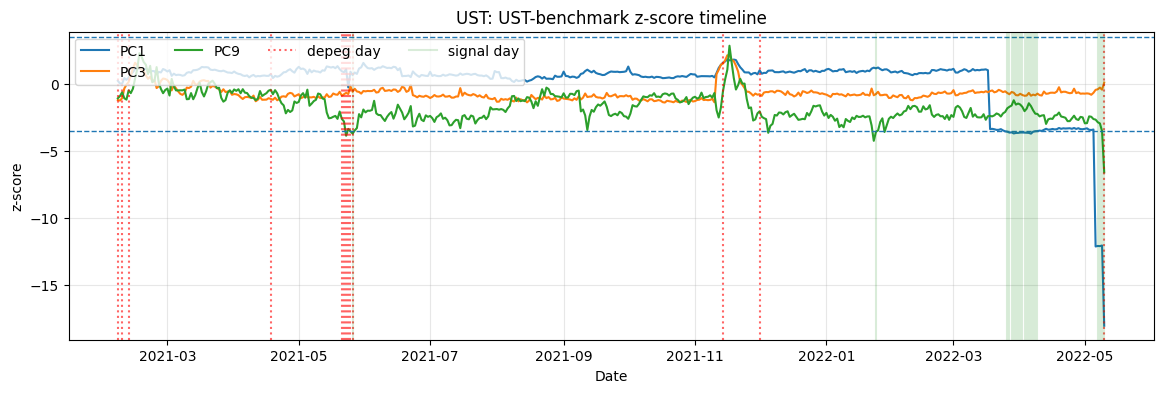

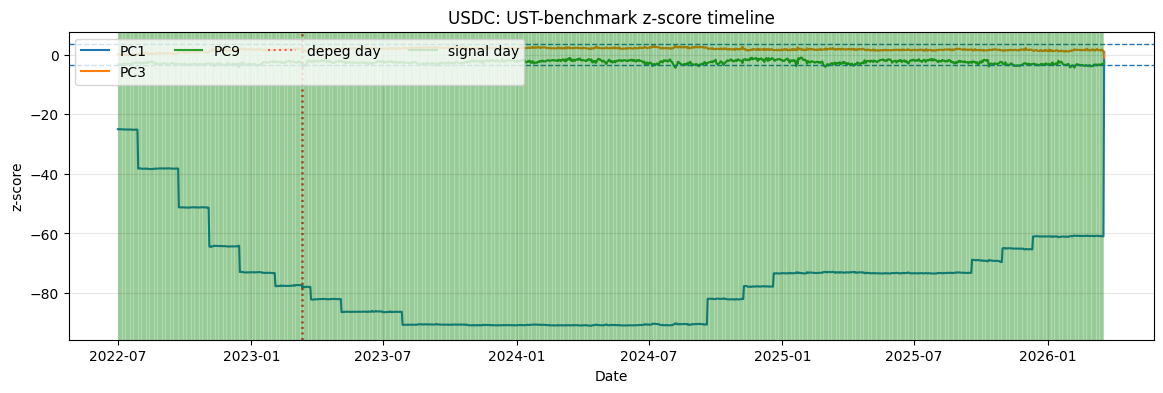

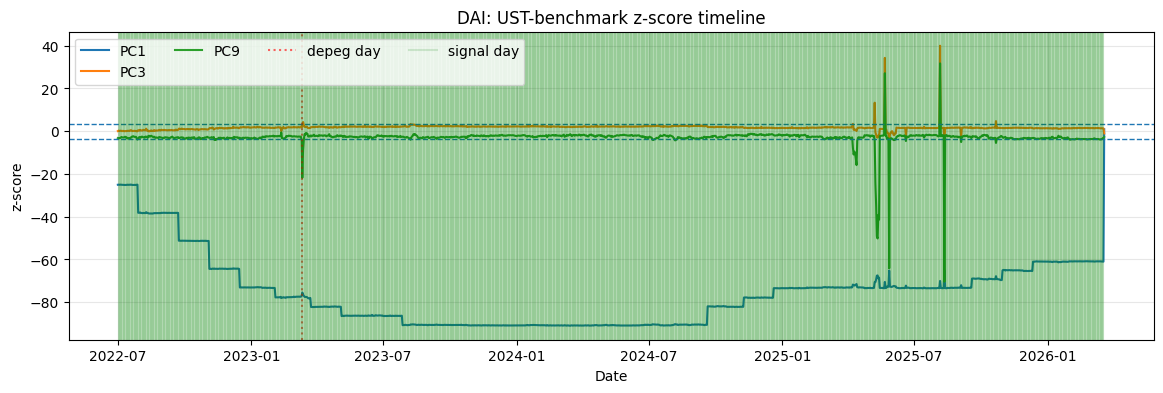

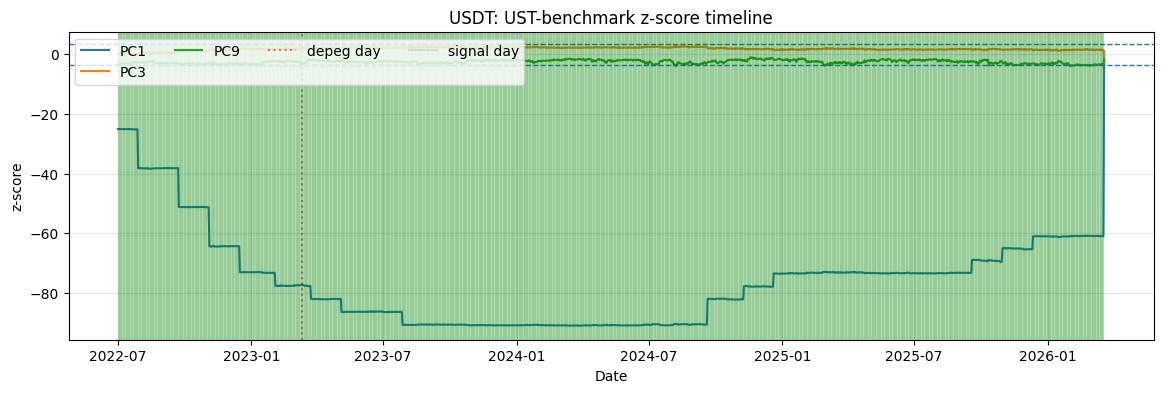

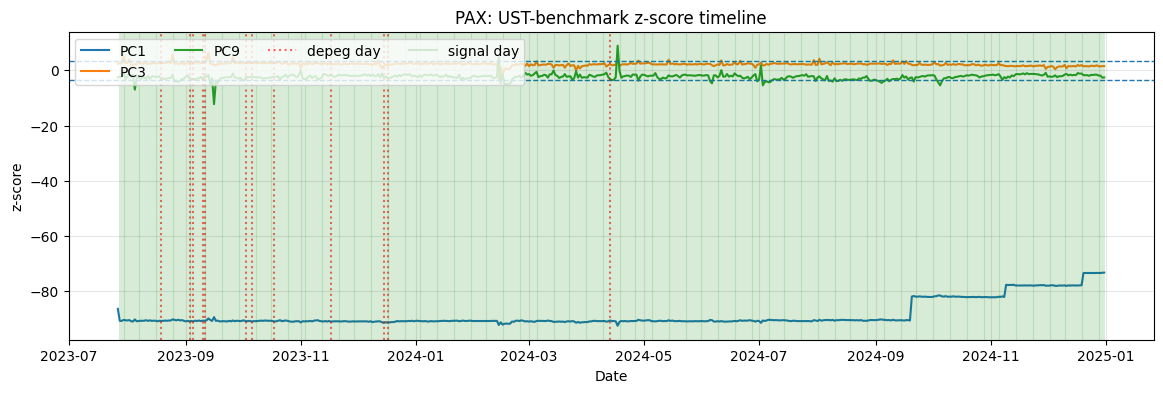

In [67]:
def plot_signal_timeline(result, threshold=3.0, figsize=(14, 4)):
    coin = result["coin"]
    df = result["labeled"].copy()

    z_cols = [c for c in df.columns if c.startswith("PC")]
    fig, ax = plt.subplots(figsize=figsize)

    for c in z_cols:
        ax.plot(df["timestamp"], df[c], label=c, linewidth=1.5)

    ax.axhline(threshold, linestyle="--", linewidth=1)
    ax.axhline(-threshold, linestyle="--", linewidth=1)

    depeg_dates = df.loc[df["depeg"] == 1, "timestamp"]
    for i, d in enumerate(depeg_dates):
        ax.axvline(d, color="red", linestyle=":", alpha=0.6,
                   label="depeg day" if i == 0 else None)

    signal_dates = df.loc[df["signal"] == 1, "timestamp"]
    for i, d in enumerate(signal_dates):
        ax.axvline(d, color="green", linestyle="-", alpha=0.15,
                   label="signal day" if i == 0 else None)

    ax.set_title(f"{coin}: UST-benchmark z-score timeline")
    ax.set_xlabel("Date")
    ax.set_ylabel("z-score")
    ax.legend(loc="upper left", ncol=4)
    ax.grid(alpha=0.3)
    plt.show()

plot_signal_timeline(ust_result, threshold=THRESHOLD)
plot_signal_timeline(usdc_result, threshold=THRESHOLD)
plot_signal_timeline(dai_result, threshold=THRESHOLD)
plot_signal_timeline(usdt_result, threshold=THRESHOLD)
plot_signal_timeline(pax_result, threshold=THRESHOLD)

## 10. Grouped Interpretation Table

This is the reporting structure for the extension.

In [60]:
grouped_results = pd.DataFrame([r["metrics"] for r in results.values()])
grouped_results["role"] = grouped_results["coin"].map({
    "UST": "Main collapse prediction",
    "USDC": "External validation",
    "DAI": "External validation",
    "USDT": "False-alarm validation",
    "PAX": "False-alarm validation",
})
grouped_results = grouped_results[[
    "role", "coin", "precision", "recall", "f1", "specificity",
    "avg_lead_time_days", "signals_per_month", "tp", "fp", "fn", "tn", "n_test_depegs"
]].sort_values(["role", "coin"])
grouped_results

,role,coin,precision,recall,f1,specificity,avg_lead_time_days,signals_per_month,tp,fp,fn,tn,n_test_depegs
2,External validation,DAI,0.005895,1.000000,0.011722,0.001480,126.500000,29.500000,8,1349,0,2,1
1,External validation,USDC,0.006632,1.000000,0.013177,0.001481,126.003922,29.500000,9,1348,0,2,2
4,False-alarm validation,PAX,0.131931,1.000000,0.233108,0.002198,32.130268,29.055556,69,454,0,1,12
3,False-alarm validation,USDT,0.005895,1.000000,0.011722,0.001480,126.500000,29.500000,8,1349,0,2,1
0,Main collapse prediction,UST,0.238095,0.098039,0.138889,0.960784,32.476190,1.312500,5,16,46,392,13


## 11. Loading Inspection

In [61]:
selected_cols = [f"PC{i+1}" for i in UST_BENCHMARK_PCS]
for col in selected_cols:
    print(f"\nTop positive loadings for {col}")
    display(ust_benchmark["loadings"][col].sort_values(ascending=False).head(10).to_frame("loading"))
    print(f"Top negative loadings for {col}")
    display(ust_benchmark["loadings"][col].sort_values(ascending=True).head(10).to_frame("loading"))


Top positive loadings for PC1


,loading
peg_error,0.365336
percent_change_30d,0.322983
percent_change_7d,0.264852
circulating_supply_percent_change_30d,0.246528
market_cap_percent_change_30d,0.235201
percent_change_24h,0.207127
volume_percent_change_7d,0.119119
volume_percent_change_30d,0.092894
volume_percent_change_24h,0.035052
circulating_supply_percent_change_24h,0.015052


Top negative loadings for PC1


,loading
realized_daily_volatility,-0.281320
fed_funds_rate,-0.268029
downward_price_deviation_5d,-0.265283
abs_peg_error,-0.247646
market_cap_percent_change_7d,-0.236533
fear_greed_index,-0.229657
market_cap_percent_change_24h,-0.213385
price_deviation_5d,-0.211038
downward_price_deviation_30d,-0.107558
circulating_supply_percent_change_7d,-0.103844



Top positive loadings for PC3


...

,loading
market_cap_percent_change_24h,-0.365687
circulating_supply_percent_change_7d,-0.236424
volume_percent_change_30d,-0.226116
circulating_supply_percent_change_24h,-0.218578
market_cap_percent_change_7d,-0.185512
percent_change_30d,-0.142782
fear_greed_index,-0.131114
abs_peg_error,-0.115254
peg_error,-0.079245
percent_change_7d,-0.072253



Top positive loadings for PC9


,loading
realized_daily_volatility,0.472985
circulating_supply_percent_change_24h,0.353164
fear_greed_index,0.252211
percent_change_7d,0.222531
abs_peg_error,0.213786
percent_change_24h,0.193432
downward_price_deviation_30d,0.148263
volume_percent_change_24h,0.110635
price_deviation_30d,0.096143
market_cap_percent_change_30d,0.046331


Top negative loadings for PC9


,loading
price_deviation_5d,-0.380647
downward_price_deviation_5d,-0.302250
volume_percent_change_7d,-0.295331
market_cap_percent_change_7d,-0.217067
circulating_supply_percent_change_7d,-0.131795
peg_error,-0.122783
volume_percent_change_30d,-0.060417
fed_funds_rate,-0.000778
percent_change_30d,0.008272
market_cap_percent_change_24h,0.029875


## 12. Sensitivity Analysis

Try different thresholds and compare precision/recall.

In [62]:
def threshold_sweep_for_all(results_input=None, thresholds=(2.0, 2.5, 3.0), consecutive_days=1, warning_window_days=7):
    out = []
    coin_inputs = {
        "UST":  (ust_test_raw,  ust_test_proj),
        "USDC": (usdc_test_raw, usdc_test_proj),
        "DAI":  (dai_test_raw,  dai_test_proj),
        "USDT": (usdt_test_raw, usdt_test_proj),
        "PAX":  (pax_test_raw,  pax_test_proj),
    }
    for thr in thresholds:
        for coin, (test_raw, proj) in coin_inputs.items():
            res = run_ust_benchmark_eval(
                coin, test_raw, proj, benchmark_stats,
                threshold=thr, consecutive_days=consecutive_days,
                warning_window_days=warning_window_days
            )
            row = res["metrics"].copy()
            row["threshold"] = thr
            out.append(row)
    return pd.DataFrame(out)

sweep_df = threshold_sweep_for_all(thresholds=(2.0, 2.5, 3.0))
sweep_df[["coin", "threshold", "precision", "recall", "f1", "specificity", "signals_per_month"]].sort_values(["coin", "threshold"])

,coin,threshold,precision,recall,f1,specificity,signals_per_month
2,DAI,2.0,0.005887,1.000000,0.011704,0.000000,29.543478
7,DAI,2.5,0.005887,1.000000,0.011704,0.000000,29.543478
12,DAI,3.0,0.005891,1.000000,0.011713,0.000740,29.521739
4,PAX,2.0,0.131679,1.000000,0.232715,0.000000,29.111111
9,PAX,2.5,0.131679,1.000000,0.232715,0.000000,29.111111
14,PAX,3.0,0.131679,1.000000,0.232715,0.000000,29.111111
1,USDC,2.0,0.006623,1.000000,0.013158,0.000000,29.543478
6,USDC,2.5,0.006623,1.000000,0.013158,0.000000,29.543478
11,USDC,3.0,0.006627,1.000000,0.013168,0.000741,29.521739
3,USDT,2.0,0.005887,1.000000,0.011704,0.000000,29.543478
